# Cyber Threat Intelligence (CTI) Machine Learning Analysis

**Performing a comprehensive Cyber Threat Intelligence (CTI) analysis using multiple machine learning models.**


In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [9]:
# loading the dataset and checking for the first few rows of the data
df = pd.read_csv('/content/Global_Cybersecurity_Threats_2015-2024.csv')
df.head()

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68


In [11]:
# defining the categorical columns
categorical_cols = ['Country', 'Target Industry', 'Attack Source', 'Security Vulnerability Type', 'Defense Mechanism Used']

# Create a LabelEncoder object
le = LabelEncoder()

# Encode each categorical column
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Features and target
feature_cols = [
    'Country', 'Year', 'Target Industry', 'Financial Loss (in Million $)',
    'Number of Affected Users', 'Attack Source', 'Security Vulnerability Type',
    'Defense Mechanism Used', 'Incident Resolution Time (in Hours)'
]
X = df[feature_cols]
y = le.fit_transform(df['Attack Type'])  # Attack Type is the classification target

In [12]:
# Standardize for KNN and KMeans
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split for supervised models
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

#Supervised Models

In [13]:
nb = GaussianNB()
nb.fit(X_train, y_train)
print("Naive Bayes Report:")
print(classification_report(y_test, nb.predict(X_test)))

Naive Bayes Report:
              precision    recall  f1-score   support

           0       0.14      0.15      0.15       111
           1       0.09      0.06      0.07        97
           2       0.06      0.01      0.02        99
           3       0.18      0.29      0.22       103
           4       0.08      0.19      0.12        79
           5       0.15      0.05      0.08       111

    accuracy                           0.12       600
   macro avg       0.12      0.13      0.11       600
weighted avg       0.12      0.12      0.11       600



In [17]:
def plot_conf_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix: {model_name}')
    plt.grid(False)
    plt.show()


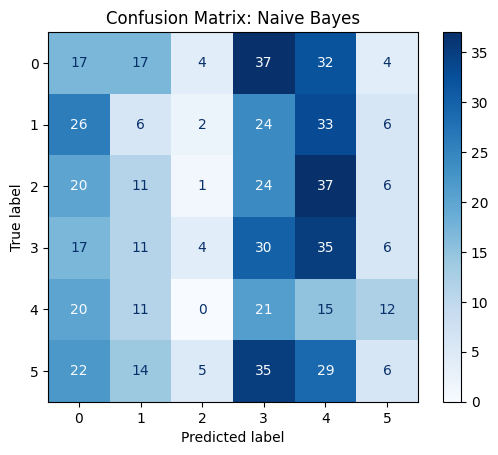

In [18]:
y_pred_nb = nb.predict(X_test)
plot_conf_matrix(y_test, y_pred_nb, "Naive Bayes")

#Model: Naive Bayes
##Role in Analysis: Baseline model for comparison
##Impact: Quick and interpretable, useful to gauge data quality. Less accurate with correlated features.

In [19]:
# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
print("KNN Report:")
print(classification_report(y_test, knn.predict(X_test)))

KNN Report:
              precision    recall  f1-score   support

           0       0.23      0.30      0.26       111
           1       0.19      0.23      0.21        97
           2       0.15      0.14      0.14        99
           3       0.11      0.10      0.10       103
           4       0.11      0.13      0.12        79
           5       0.18      0.11      0.14       111

    accuracy                           0.17       600
   macro avg       0.16      0.17      0.16       600
weighted avg       0.16      0.17      0.16       600



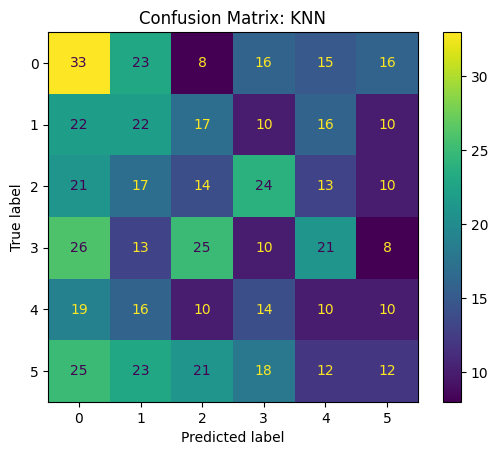

In [40]:
y_pred_knn = knn.predict(X_test)
cm=confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='viridis')  # 👈 Change color map here
plt.title('Confusion Matrix: KNN')
plt.grid(False)
plt.show()


#Model: KNN
##Role in Analysis: Pattern matching based on proximity
##Impact: Good at capturing local relationships. Struggles with high dimensional data unless scaled.

In [20]:
#Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print("Random Forest Report:")
print(classification_report(y_test, rf.predict(X_test)))

Random Forest Report:
              precision    recall  f1-score   support

           0       0.16      0.18      0.17       111
           1       0.16      0.16      0.16        97
           2       0.15      0.11      0.13        99
           3       0.15      0.15      0.15       103
           4       0.09      0.13      0.11        79
           5       0.19      0.15      0.17       111

    accuracy                           0.15       600
   macro avg       0.15      0.15      0.15       600
weighted avg       0.15      0.15      0.15       600



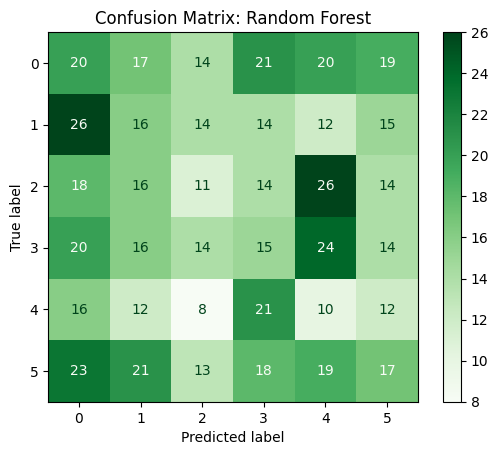

In [26]:
y_pred_rf = rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Greens')  # 👈 Change color map here
plt.title('Confusion Matrix: Random Forest')
plt.grid(False)
plt.show()


#Model: Random Forest
##Role in Analysis: Tree-based ensemble
##Impact: Handles non-linearities and interactions well. Provides feature importance to explain model behavior.

In [21]:
#Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
print("Gradient Boosting Report:")
print(classification_report(y_test, gb.predict(X_test)))

Gradient Boosting Report:
              precision    recall  f1-score   support

           0       0.15      0.15      0.15       111
           1       0.13      0.10      0.12        97
           2       0.17      0.13      0.15        99
           3       0.19      0.19      0.19       103
           4       0.08      0.11      0.10        79
           5       0.17      0.19      0.18       111

    accuracy                           0.15       600
   macro avg       0.15      0.15      0.15       600
weighted avg       0.15      0.15      0.15       600



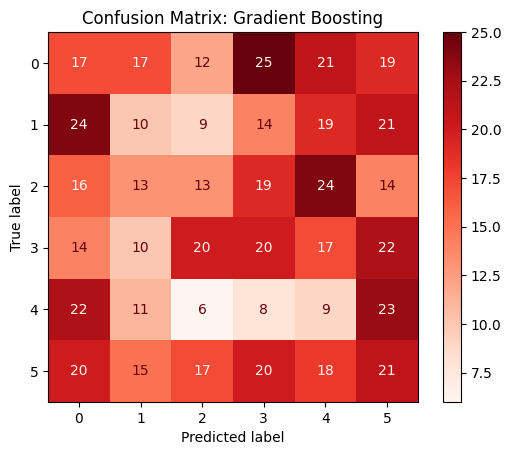

In [39]:
y_pred_gb = gb.predict(X_test)
cm=confusion_matrix(y_test, y_pred_gb,)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Reds')  # 👈 Change color map here
plt.title('Confusion Matrix: Gradient Boosting')
plt.grid(False)
plt.show()


#Model: Gradient Boosting
##Role in Analysis: 	Boosted tree ensemble
##Impact: Focuses on hard-to-classify cases. Often gives the best performance, though slower to train.

In [22]:
# Voting Classifier
voting = VotingClassifier(estimators=[
    ('nb', nb), ('knn', knn), ('rf', rf)
], voting='hard')
voting.fit(X_train, y_train)
print("Voting Classifier Report:")
print(classification_report(y_test, voting.predict(X_test)))

Voting Classifier Report:
              precision    recall  f1-score   support

           0       0.19      0.39      0.26       111
           1       0.15      0.16      0.16        97
           2       0.14      0.09      0.11        99
           3       0.14      0.13      0.13       103
           4       0.07      0.08      0.07        79
           5       0.24      0.06      0.10       111

    accuracy                           0.16       600
   macro avg       0.16      0.15      0.14       600
weighted avg       0.16      0.16      0.14       600



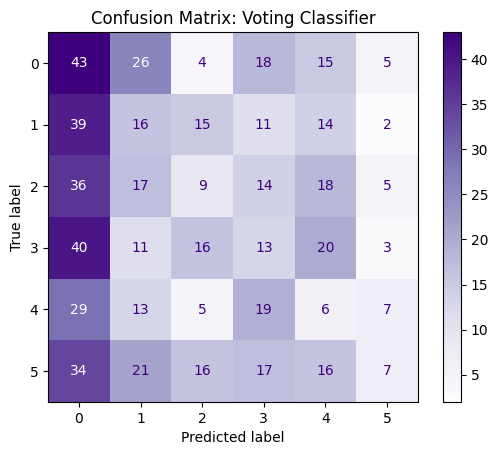

In [41]:
y_pred_vote = voting.predict(X_test)
cm=confusion_matrix(y_test, y_pred_vote)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Purples')  # 👈 Change color map here
plt.title('Confusion Matrix: Voting Classifier')
plt.grid(False)
plt.show()

#Model: Voting Classifier
##Role in Analysis: 	Combines multiple models
##Impact: Reduces individual model biases and variance, improves robustness of predictions.

<ipython-input-34-f1f9812ee8e4>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(accuracy_scores.keys()), y=list(accuracy_scores.values()), palette="viridis")


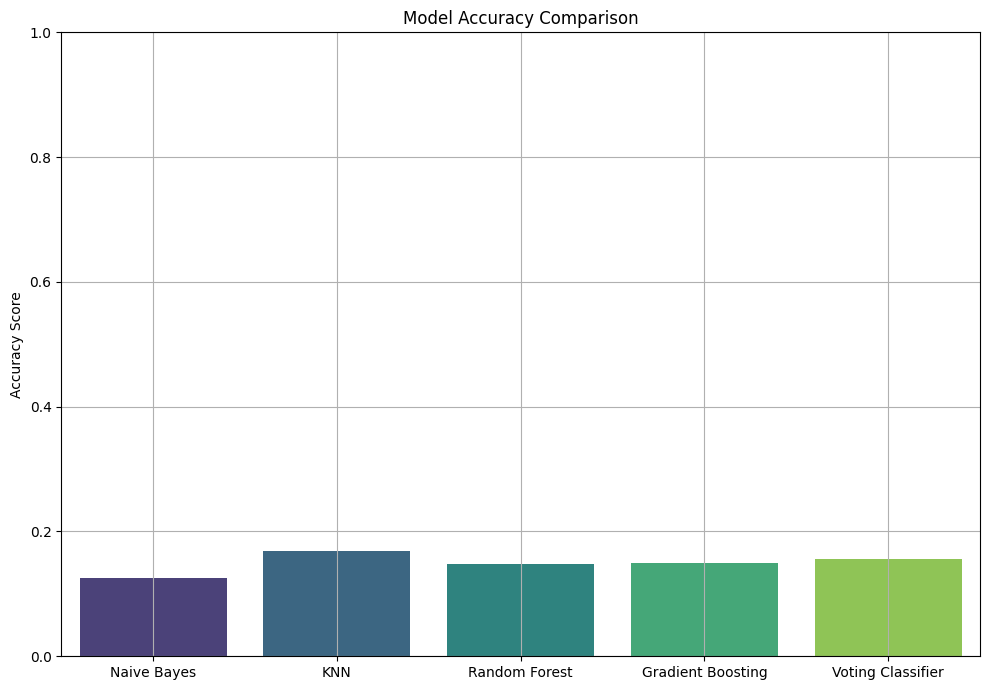

In [34]:
#Accuracy comparision plot
accuracy_scores = {
    "Naive Bayes": accuracy_score(y_test, y_pred_nb),
    "KNN": accuracy_score(y_test, y_pred_knn),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "Gradient Boosting": accuracy_score(y_test, y_pred_gb),
    "Voting Classifier": accuracy_score(y_test, y_pred_vote),
}

plt.figure(figsize=(10, 7))
sns.barplot(x=list(accuracy_scores.keys()), y=list(accuracy_scores.values()), palette="viridis")
plt.ylabel("Accuracy Score")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)
plt.grid(True)
plt.tight_layout()
plt.show()


##This model accuracy comparison plot is extremely useful as it provides a clear, visual evaluation of how well each model performs in Cyber Threat Intelligence (CTI) analysis process.
#🎯 Why This Plot Is Useful:
#✅ 1. Quick Performance Benchmarking
##The bar chart instantly shows which models perform best on your dataset:

##Helps identify the most reliable model for classifying cyber threats.

##Saves time compared to sifting through long classification reports.

#🔍 2. Model Selection Made Easy
## You can choose the best-performing model based on accuracy.

#⚖️ 3. Evaluate the Value of Ensemble Methods
## Seeing how the Voting Classifier compares helps you evaluate the benefit of combining models.

## If Voting outperforms individual models, it suggests model diversity leads to better generalization.

#🧠 Strategic Implications for CTI
##In real-world cybersecurity:

##Accuracy = Trustworthiness of predictions (e.g., predicting attack type before it happens).

##High accuracy from models like Random Forest or Gradient Boosting means you can automate threat classification with confidence.

##Poor performance from a model could indicate missing features, noisy data, or a need for tuning.

#🧩 Final Takeaway:
This plot turns raw metrics into actionable intelligence by visually ranking models, guiding you in:

##Selecting the right model for deployment.

C##ommunicating findings clearly to non-technical stakeholders (e.g., cybersecurity teams, policy makers).

#Adding an unsupervised learning perspective to the Cyber Threat Intelligence (CTI) analysis, by applying K-Means Clustering with PCA visualization.

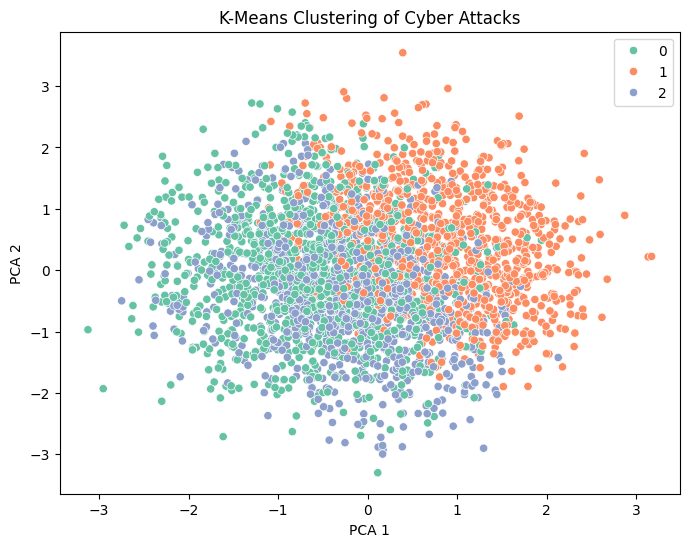

In [45]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Visualizing with PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], hue=clusters, palette='Set2')
plt.title("K-Means Clustering of Cyber Attacks")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

#🧠 Why This Is Useful:

#✅ 1. Uncovers Hidden Groupings
##K-Means groups the data based on patterns without using the 'Attack Type' label. This is valuable because:

##It may reveal underlying structures in the data that the classification models didn't explicitly capture.

##It helps detect novel or emerging threat patterns that don't neatly fit existing categories.

#🔍 2. Cluster Profiles Can Inform CTI
##By analyzing each cluster’s characteristics (e.g., average financial loss, common vulnerability types), you can:

##Profile different types of threat behaviors.

##Detect anomalous patterns that may indicate coordinated attacks or new APT (Advanced Persistent Threat) groups.

##Target defense strategies based on the cluster's threat signature, even without prior labels.

#🌐 3. Complement to Supervised Learning
##Supervised models predict known attack types. Clustering goes further by:

##Discovering latent groupings across industries, countries, and vulnerabilities.

##Helping in early threat detection when labeled data is sparse or delayed.

# ***What You Learn from This CTI Analysis***
## 1. Classification of Attack Types
###Making use of features like Country, Industry, Attack Source, Vulnerability Type, and others to predict the Attack Type. This helps in:

###Anticipating likely threats for different environments (e.g., industries in certain countries).

###Identifying the most vulnerable sectors or vectors.


## 2. Feature Importance (via Ensemble Models)
###Models like Random Forest and Gradient Boosting allows to examine which features (e.g., "Vulnerability Type", "Defense Mechanism Used") are most influential in attack prediction. This can guide:

###Proactive patching of specific vulnerabilities.

###Deployment of more effective defenses in key sectors.

## 3. Model Comparison Gives Strategic Insights:
###By applying different models, you learn which is best suited for your data — each has tradeoffs in terms of accuracy, complexity, and interpretability.